# FRED Indicators Query — CPI, Inflation, and Core Macro Series

This notebook exercises `src/fred_api`, a standalone client for FRED's REST API
(`api.stlouisfed.org`), kept separate from the `macro_data` package (which fetches
only two FRED series today, `us_cpi` and `fed_funds_rate`, through the
catalog/schema/store pipeline — see `macro_data/sources/fred.py`). Nothing queried
here is written to `data/`; this is ad-hoc exploration, same spirit as
`BOT_query.ipynb` and `worldbank_gep_forecast.ipynb`.

Sections:
1. Setup — construct a `FREDClient`, define a `fetch_series()` helper
2. CPI — headline (`CPIAUCSL`) vs. core (`CPILFESL`), index levels
3. Inflation, three ways — headline CPI, core CPI, and PCE (`PCEPI`) year-over-year %
4. Unemployment rate (`UNRATE`)
5. Fed funds rate (`FEDFUNDS`) vs. headline inflation
6. Real GDP growth (`GDPC1`), year-over-year %
7. Notes — scope and how to get ongoing tracking instead of ad-hoc queries

## 1. Setup

`FREDClient()` reads `FRED_API_KEY` from the environment (same key `macro_data`'s
`fred` source uses). `fetch_series()` wraps `client.series.observations()` and cleans
the result: FRED returns `date`/`value` as strings (with `"."` for missing
observations in general, though none of the series below hit that), so this converts
types, drops unparseable rows, and sets `date` as the index — the notebook's own
light cleanup, not `macro_data.schema.normalize` (that function is internal to the
package pipeline and isn't imported here).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from fred_api import FREDClient

load_dotenv(Path("..") / ".env")
pd.set_option("display.max_columns", 10)
%matplotlib inline

fred = FREDClient()  # reads FRED_API_KEY from the environment
print(f"FREDClient ready, base_url={fred.base_url}")


def fetch_series(series_id: str, from_date: str = "2000-01-01") -> pd.DataFrame:
    """Fetch a FRED series and return it indexed by date with a numeric value column."""
    df = fred.series.observations(series_id, from_date=from_date)
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"]).set_index("date")
    return df[["value"]]

FREDClient ready, base_url=https://api.stlouisfed.org/fred/


## 2. CPI — headline vs. core

`CPIAUCSL` (headline, all urban consumers) and `CPILFESL` (core, ex food & energy),
both index levels (1982-84=100), monthly, from 2000 onward.

Headline CPI (CPIAUCSL):


,value
date,
2026-02-01,327.460
2026-03-01,330.293
2026-04-01,332.407
2026-05-01,333.979
2026-06-01,332.568


Core CPI (CPILFESL):


,value
date,
2026-02-01,333.512
2026-03-01,334.165
2026-04-01,335.423
2026-05-01,336.121
2026-06-01,336.065


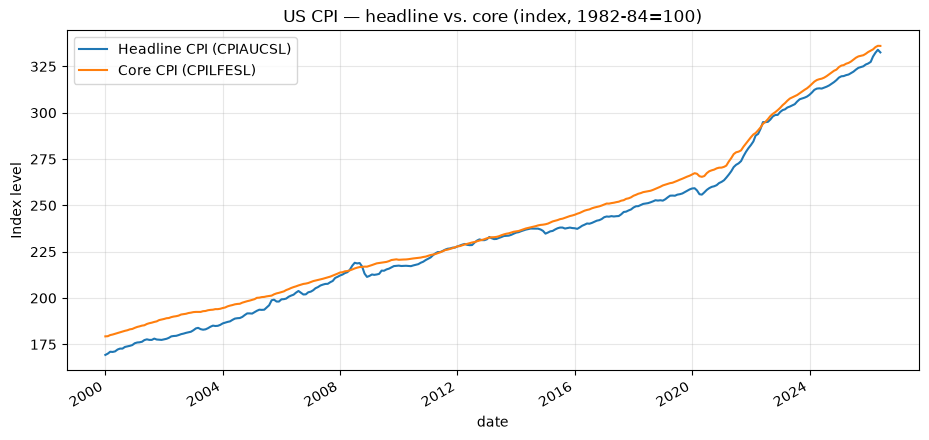

In [2]:
cpi_headline = fetch_series("CPIAUCSL")
cpi_core = fetch_series("CPILFESL")

print("Headline CPI (CPIAUCSL):")
display(cpi_headline.tail())
print("Core CPI (CPILFESL):")
display(cpi_core.tail())

fig, ax = plt.subplots(figsize=(11, 5))
cpi_headline["value"].plot(ax=ax, label="Headline CPI (CPIAUCSL)")
cpi_core["value"].plot(ax=ax, label="Core CPI (CPILFESL)")
ax.set_title("US CPI — headline vs. core (index, 1982-84=100)")
ax.set_ylabel("Index level")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 3. Inflation, three ways

CPI and PCE are index *levels*, not inflation rates — FRED doesn't hand back a
pre-computed rate for these series IDs. Inflation here is derived as year-over-year
percent change (`pct_change(12) * 100` on monthly index series): headline CPI, core
CPI, and PCE (`PCEPI`, the Fed's preferred inflation gauge) side by side.

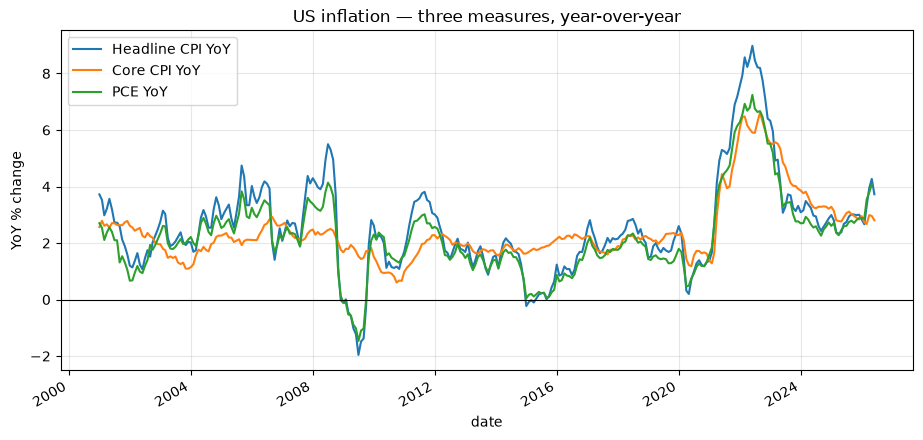

,headline_cpi_yoy,core_cpi_yoy,pce_yoy
date,,,
2026-02-01,2.664589,2.733506,2.873230
2026-03-01,3.320206,2.673098,3.542929
2026-04-01,3.947027,2.988425,3.795482
2026-05-01,4.270033,2.957114,4.072638
2026-06-01,3.726530,2.805811,NaN


In [3]:
pce = fetch_series("PCEPI")

headline_inflation = cpi_headline["value"].pct_change(12) * 100
core_inflation = cpi_core["value"].pct_change(12) * 100
pce_inflation = pce["value"].pct_change(12) * 100

fig, ax = plt.subplots(figsize=(11, 5))
headline_inflation.plot(ax=ax, label="Headline CPI YoY")
core_inflation.plot(ax=ax, label="Core CPI YoY")
pce_inflation.plot(ax=ax, label="PCE YoY")
ax.set_title("US inflation — three measures, year-over-year")
ax.set_ylabel("YoY % change")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

pd.DataFrame(
    {
        "headline_cpi_yoy": headline_inflation,
        "core_cpi_yoy": core_inflation,
        "pce_yoy": pce_inflation,
    }
).tail()